In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, Rescaling
)
from tensorflow.keras.optimizers import Adam


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
DATA_DIR = "DataClean"
OPEN_DIR = os.path.join(DATA_DIR, "open")
CLOSE_DIR = os.path.join(DATA_DIR, "close")

img_size = 224


In [3]:
X = []
y = []

def load_images(folder, label):
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        X.append(img)
        y.append(label)

load_images(OPEN_DIR, 1)   # open eyes = 1
load_images(CLOSE_DIR, 0)  # closed eyes = 0

X = np.array(X, dtype=np.uint8)   # 🔴 KEEP uint8
y = np.array(y)

X = X.reshape(-1, img_size, img_size, 1)

print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("y shape:", y.shape)


X shape: (84898, 224, 224, 1)
X dtype: uint8
y shape: (84898,)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

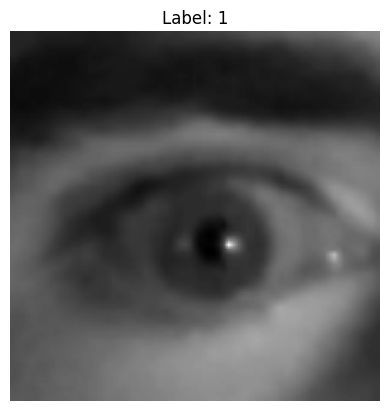

In [4]:
plt.imshow(X[0].squeeze(), cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis("off")


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (67918, 224, 224, 1)
Test : (16980, 224, 224, 1)


In [6]:
model = Sequential([
    Rescaling(1./255, input_shape=(224, 224, 1)),

    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    # epochs=10,
    epochs=1,
    batch_size=8   # 🔴 keep small
)


8490/8490 ━━━━━━━━━━━━━━━━━━━━ 1183s 139ms/step - accuracy: 0.9156 - loss: 0.2179 - val_accuracy: 0.9529 - val_loss: 0.1295


In [8]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")


531/531 ━━━━━━━━━━━━━━━━━━━━ 60s 112ms/step - accuracy: 0.9529 - loss: 0.1295
Test Accuracy: 0.9529


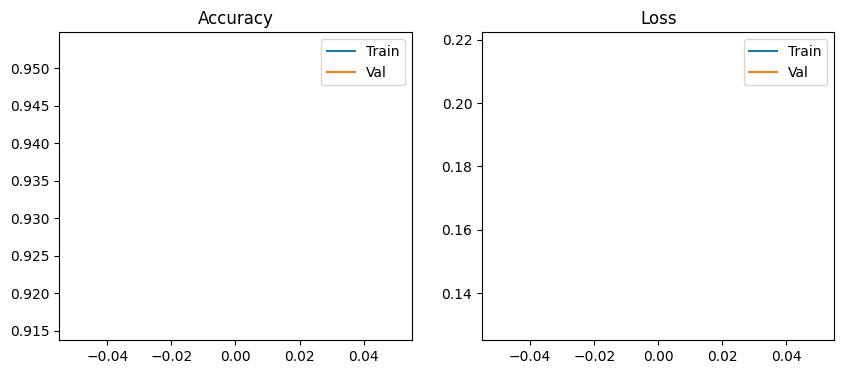

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.show()


In [19]:
model.save("drowsiness_eye_model.h5")
print("Model saved!")


Model saved!


In [16]:
img = cv2.imread("/Users/chhaykim/Desktop/ai_project_tp/DataClean/close/s0001_s0001_00001_0_0_0_0_0_01.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224,224))
img = img.reshape(1,224,224,1)

pred = model.predict(img)[0][0]

if pred > 0.5:
    print("OPEN EYES")
else:
    print("CLOSED EYES")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
CLOSED EYES


In [15]:
img = cv2.imread("/Users/chhaykim/Desktop/ai_project_tp/DataClean/open/s0001_s0001_01842_0_0_1_0_0_01.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224,224))
img = img.reshape(1,224,224,1)

pred = model.predict(img)[0][0]

if pred > 0.5:
    print("OPEN EYES")
else:
    print("CLOSED EYES")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
OPEN EYES


In [28]:
img = cv2.imread("/Users/chhaykim/Desktop/ai_project_tp/download.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224,224))
img = img.reshape(1,224,224,1)

pred = model.predict(img)[0][0]

if pred > 0.5:
    print("OPEN EYES")
else:
    print("CLOSED EYES")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
OPEN EYES


In [53]:
import cv2
import numpy as np

# Load and preprocess image
# img = cv2.imread("/Users/chhaykim/Desktop/ai_tp_project/close1.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.imread("/Users/chhaykim/Desktop/ai_tp_project/close.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224, 224))
img = img.astype('float32') / 255.0
img = img.reshape(1, 224, 224, 1)

# Get prediction
pred = model.predict(img, verbose=0)[0][0]

# CORRECTED: 0=Open, 1=Closed
if pred > 0.5:
    print(f"CLOSED EYES (confidence: {pred:.2%})")
else:
    print(f"OPEN EYES (confidence: {(1-pred):.2%})")

CLOSED EYES (confidence: 99.81%)


In [32]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model


In [20]:
model = load_model("drowsiness_eye_model.h5")
print("Model loaded successfully")


Model loaded successfully


In [21]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)


In [22]:
IMG_SIZE = 224

def preprocess_eye(eye_img):
    eye_img = cv2.resize(eye_img, (IMG_SIZE, IMG_SIZE))
    eye_img = eye_img.reshape(1, IMG_SIZE, IMG_SIZE, 1)
    return eye_img  # uint8 → normalized in model


In [25]:
cap = cv2.VideoCapture(1)

closed_count = 0
DROWSY_THRESHOLD = 20  # frames

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    status = "NO FACE"

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x,y), (x+w, y+h), (255,0,0), 2)
        roi_gray = gray[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray, 1.3, 5)

        for (ex, ey, ew, eh) in eyes:
            eye_img = roi_gray[ey:ey+eh, ex:ex+ew]
            eye_input = preprocess_eye(eye_img)

            prediction = model.predict(eye_input, verbose=0)[0][0]

            if prediction < 0.5:
                closed_count += 1
                status = "EYES CLOSED"
            else:
                closed_count = 0
                status = "EYES OPEN"

            cv2.rectangle(
                frame,
                (x+ex, y+ey),
                (x+ex+ew, y+ey+eh),
                (0,255,0),
                2
            )
            break

    # DROWSINESS ALERT
    if closed_count >= DROWSY_THRESHOLD:
        cv2.putText(
            frame, "DROWSY ALERT!",
            (50, 80),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.5, (0,0,255), 3
        )

    cv2.putText(
        frame, status,
        (30, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1, (0,255,0), 2
    )

    cv2.imshow("Drowsiness Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


OpenCV: not authorized to capture video (status 0), requesting...
OpenCV: camera failed to properly initialize!


In [24]:
import cv2

cap = cv2.VideoCapture(0)
print(cap.isOpened())


False


OpenCV: not authorized to capture video (status 0), requesting...
OpenCV: camera failed to properly initialize!
